In [1]:
pip install opencv-python "numpy<2" matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/Users/230108/Downloads/images-2.jpeg', cv2.IMREAD_GRAYSCALE)

#  Challenge 1: Kernel Size Experiment

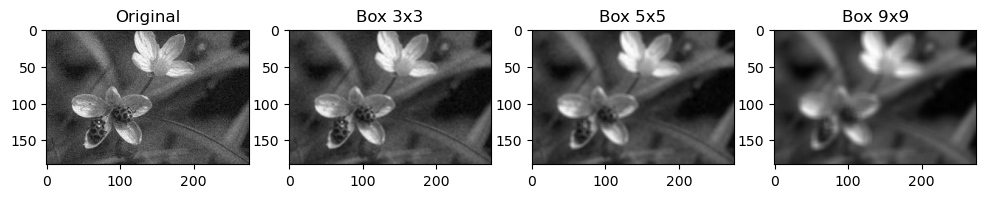

In [3]:
box3 = cv2.blur(image, (3,3))
box5 = cv2.blur(image, (5,5))
box9 = cv2.blur(image, (9,9))

plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(box3, cmap='gray')
plt.title("Box 3x3")

plt.subplot(1,4,3)
plt.imshow(box5, cmap='gray')
plt.title("Box 5x5")

plt.subplot(1,4,4)
plt.imshow(box9, cmap='gray')
plt.title("Box 9x9")

plt.show()

##  Challenge 2: Gaussian Sigma Investigation

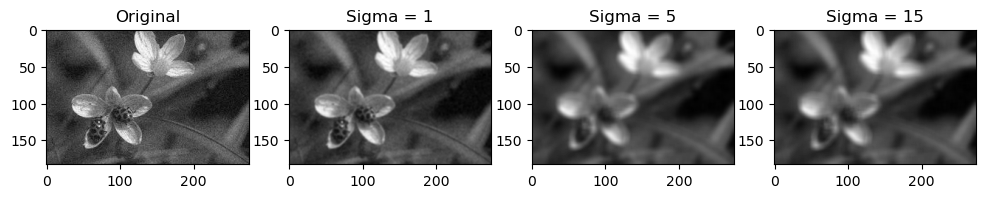

In [4]:
gauss1 = cv2.GaussianBlur(image, (9,9), 1)
gauss5 = cv2.GaussianBlur(image, (9,9), 5)
gauss15 = cv2.GaussianBlur(image, (9,9), 15)

plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(gauss1, cmap='gray')
plt.title("Sigma = 1")

plt.subplot(1,4,3)
plt.imshow(gauss5, cmap='gray')
plt.title("Sigma = 5")

plt.subplot(1,4,4)
plt.imshow(gauss15, cmap='gray')
plt.title("Sigma = 15")

plt.show()

##  Challenge 3: Manual Convolution

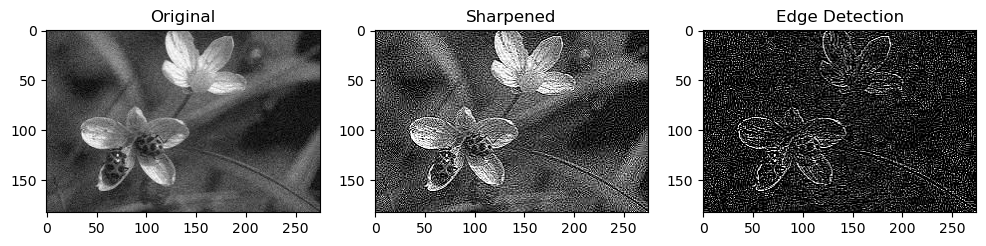

In [5]:
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

edge_kernel = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

sharpened = cv2.filter2D(image, -1, sharpen_kernel)
edges = cv2.filter2D(image, -1, edge_kernel)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened")

plt.subplot(1,3,3)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")

plt.show()

##  Challenge 4: Noise Removal Test

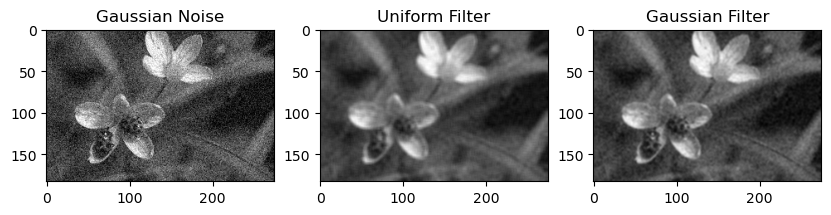

In [6]:
gaussian_noise = image + np.random.normal(0,20,image.shape)
gaussian_noise = np.clip(gaussian_noise,0,255).astype(np.uint8)

uniform = cv2.blur(gaussian_noise,(5,5))
gaussian = cv2.GaussianBlur(gaussian_noise,(5,5),0)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(gaussian_noise, cmap='gray')
plt.title("Gaussian Noise")

plt.subplot(1,3,2)
plt.imshow(uniform, cmap='gray')
plt.title("Uniform Filter")

plt.subplot(1,3,3)
plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian Filter")

plt.show()


##  Challenge 5: Edge Preservation Study

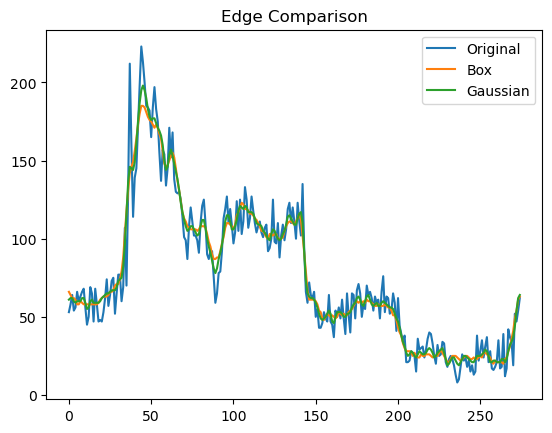

In [7]:
box = cv2.blur(image,(5,5))
gauss = cv2.GaussianBlur(image,(5,5),0)

row = 100

plt.plot(image[row,:], label="Original")
plt.plot(box[row,:], label="Box")
plt.plot(gauss[row,:], label="Gaussian")

plt.legend()
plt.title("Edge Comparison")
plt.show()


##  Challenge 6: Performance Comparison

In [9]:
import time

runs = 50

start = time.time()
for i in range(runs):
    cv2.filter2D(image,-1,np.ones((5,5))/25)
end = time.time()

time_filter2d = (end-start)/runs

start = time.time()
for i in range(runs):
    cv2.GaussianBlur(image,(5,5),0)
end = time.time()

time_gaussian = (end-start)/runs

print("Average time filter2D:", time_filter2d)
print("Average time GaussianBlur:", time_gaussian)

Average time filter2D: 0.00047330379486083986
Average time GaussianBlur: 5.88226318359375e-05


##  Challenge 7: Kernel Normalization Test

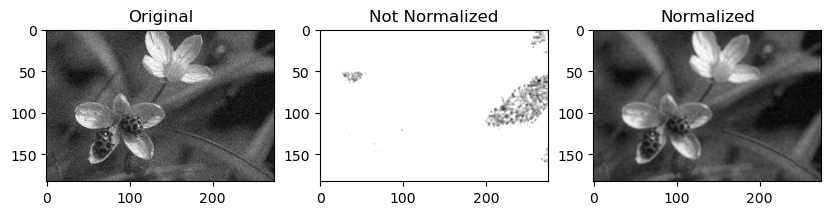

In [10]:
kernel = np.ones((3,3))

not_norm = cv2.filter2D(image,-1,kernel)

kernel_norm = kernel / np.sum(kernel)

norm = cv2.filter2D(image,-1,kernel_norm)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(not_norm, cmap='gray')
plt.title("Not Normalized")

plt.subplot(1,3,3)
plt.imshow(norm, cmap='gray')
plt.title("Normalized")

plt.show()

#  Final Challenge: Smart Filter Selector

In [11]:
print("Choose filter:")
print("1 - Uniform Filter")
print("2 - Gaussian Filter")

choice = input("Enter 1 or 2: ")

# Ask for kernel size
k = int(input("Enter kernel size (odd number like 3,5,7): "))

# Apply selected filter
if choice == "1":
    filtered = cv2.blur(image, (k, k))
    title = "Uniform Filter"

elif choice == "2":
    sigma = float(input("Enter sigma value: "))
    filtered = cv2.GaussianBlur(image, (k, k), sigma)
    title = "Gaussian Filter"

else:
    print("Invalid choice")
    exit()

# Display images
plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(filtered, cmap="gray")
plt.title(title)
plt.axis("off")

plt.show()

[ WARN:0@263.036] global loadsave.cpp:268 findDecoder imread_('image.png'): can't open/read file: check file path/integrity


Choose filter:
1 - Uniform Filter
2 - Gaussian Filter


Enter 1 or 2:  2
Enter kernel size (odd number like 3,5,7):  3
Enter sigma value:  filter


ValueError: could not convert string to float: 'filter'